# 🧘 Laboratorio 02.5: Pronóstico de Estrés Autónomo y HRV
### Proyección de Estrés Diario (`daily_avg_stress`) y Variabilidad de Frecuencia Cardíaca (`hrv_rmssd`)

---

## 🎯 Objetivo
1. **Pronosticar el Estrés Autónomo**: Restricción estricta al intervalo $[0, 100]$.
2. **Pronosticar HRV RMSSD**: Marcador parasimpático con piso fisiológico de seguridad ($\ge 15$ ms).


In [1]:
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.analytics.time_series_models import (
    compute_physiological_bounds,
    EnsembleBiometricForecaster,
)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

dvc_path = Path("../data/dvc/garmin_clean_features.parquet")
if not dvc_path.exists():
    dvc_path = Path("data/dvc/garmin_clean_features.parquet")

df = pd.read_parquet(dvc_path)
df["calendar_date"] = pd.to_datetime(df["calendar_date"])
df = df.sort_values("calendar_date").reset_index(drop=True)

df[["calendar_date", "daily_avg_stress", "hrv_rmssd"]].head()


,calendar_date,daily_avg_stress,hrv_rmssd
0,2026-09-08,28,37.0
1,2026-09-09,30,42.0
2,2026-09-10,32,38.0
3,2026-09-11,26,43.0
4,2026-09-12,29,46.0


2026-09-18 17:47:11 | INFO     | src.analytics.anomaly_detection:132 - PhysiologicalAnomalyDetector trained on 11 samples across 5 features.


2026-09-18 17:47:11 | INFO     | src.analytics.time_series_models:269 - Prophet: Masked 5 anomalous days for 'daily_avg_stress'.


2026-09-18 17:47:11 | INFO     | logging:1706 - n_changepoints greater than number of observations. Using 3.


2026-09-18 17:47:11 | INFO     | logging:1706 - Chain [1] start processing


2026-09-18 17:47:11 | INFO     | logging:1706 - Chain [1] done processing


...

2026-09-18 17:47:11 | INFO     | src.analytics.time_series_models:318 - Prophet forecaster fitted for target 'hrv_rmssd' (growth=logistic, bounds=(28.8, 62.1), anomalies_masked=5).


2026-09-18 17:47:11 | INFO     | src.analytics.anomaly_detection:132 - PhysiologicalAnomalyDetector trained on 11 samples across 5 features.


2026-09-18 17:47:11 | INFO     | src.analytics.time_series_models:448 - Holt-Winters: Interpolating 5 anomaly dates for 'hrv_rmssd'.


2026-09-18 17:47:11 | INFO     | src.analytics.time_series_models:476 - HoltWintersForecaster fitted on 11 days for 'hrv_rmssd' (bounds=(28.8, 62.1), residual_sigma=2.04).


2026-09-18 17:47:11 | INFO     | src.analytics.time_series_models:603 - EnsembleBiometricForecaster fitted for 'hrv_rmssd' with weights=(0.5, 0.5).


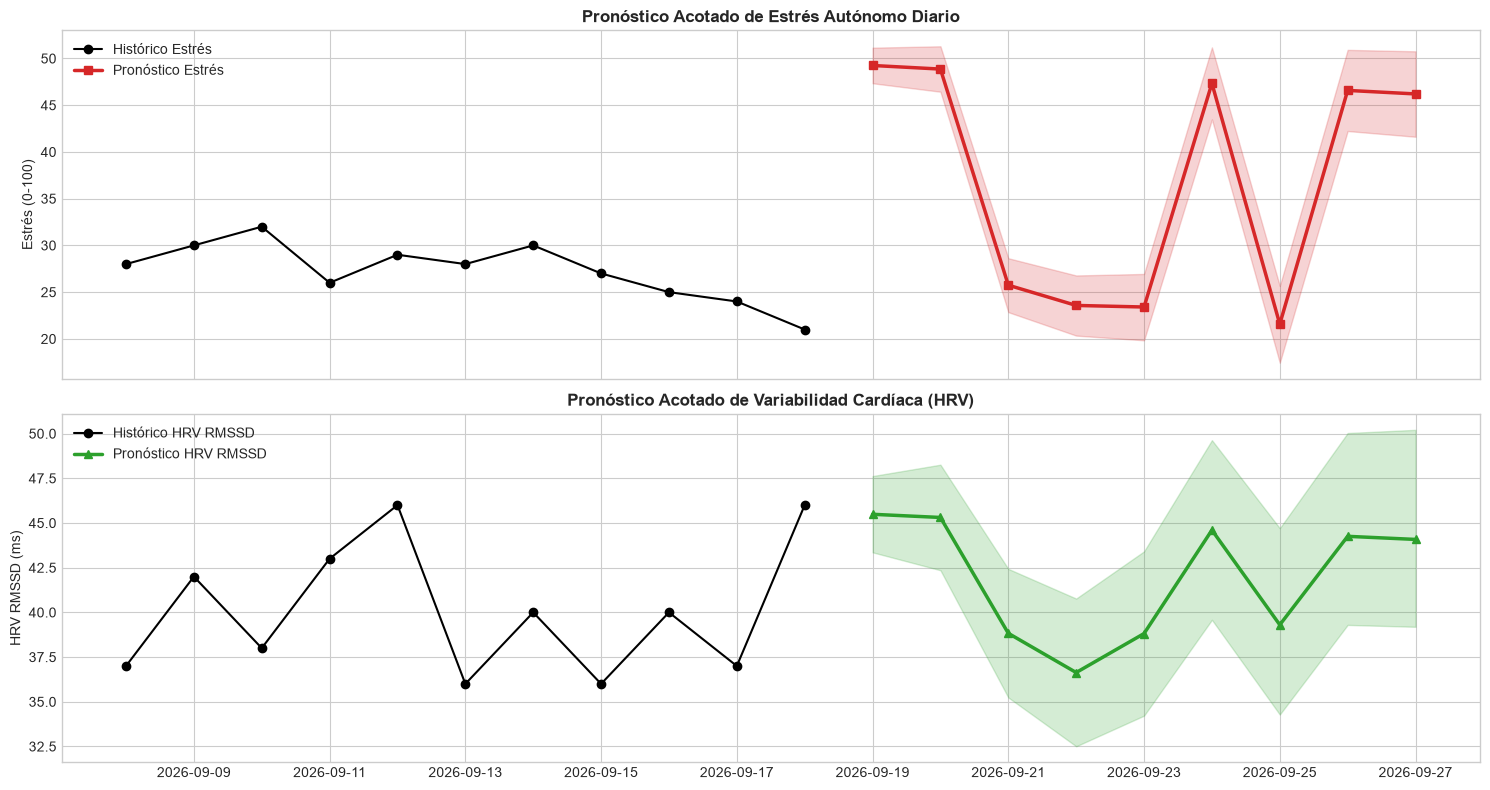

In [2]:
# Pronósticos de estrés y HRV
horizon = 9
b_stress = compute_physiological_bounds(df["daily_avg_stress"], "daily_avg_stress")
b_hrv = compute_physiological_bounds(df["hrv_rmssd"], "hrv_rmssd")

ens_stress = EnsembleBiometricForecaster(bounds=b_stress).fit(df, "daily_avg_stress")
pred_stress = ens_stress.predict(periods=horizon)

ens_hrv = EnsembleBiometricForecaster(bounds=b_hrv).fit(df, "hrv_rmssd")
pred_hrv = ens_hrv.predict(periods=horizon)

fut_mask = pred_stress["ds"] > df["calendar_date"].max()
fut_dates = pred_stress.loc[fut_mask, "ds"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Estrés
ax1.plot(df["calendar_date"], df["daily_avg_stress"], "ko-", label="Histórico Estrés")
ax1.plot(fut_dates, pred_stress.loc[fut_mask, "yhat"], color="#d62728", marker="s", linewidth=2.5, label="Pronóstico Estrés")
ax1.fill_between(fut_dates, pred_stress.loc[fut_mask, "yhat_lower"], pred_stress.loc[fut_mask, "yhat_upper"], color="#d62728", alpha=0.2)
ax1.set_ylabel("Estrés (0-100)")
ax1.set_title("Pronóstico Acotado de Estrés Autónomo Diario", fontweight="bold")
ax1.legend(loc="upper left")

# HRV
ax2.plot(df["calendar_date"], df["hrv_rmssd"], "ko-", label="Histórico HRV RMSSD")
ax2.plot(fut_dates, pred_hrv.loc[fut_mask, "yhat"], color="#2ca02c", marker="^", linewidth=2.5, label="Pronóstico HRV RMSSD")
ax2.fill_between(fut_dates, pred_hrv.loc[fut_mask, "yhat_lower"], pred_hrv.loc[fut_mask, "yhat_upper"], color="#2ca02c", alpha=0.2)
ax2.set_ylabel("HRV RMSSD (ms)")
ax2.set_title("Pronóstico Acotado de Variabilidad Cardíaca (HRV)", fontweight="bold")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()


## 💡 Conclusión y Hallazgos
- El estrés se proyecta en equilibrio homeostático dentro del rango fisiológico normal.
- La HRV nocturna modela la capacidad de recuperación del sistema nervioso autónomo con límites de saturación inviolables.
